## Preprocessing the text

In [9]:
import nltk
import re
nltk.download('stopwords')
text = """Beans. I was trying to explain to somebody as we were flying in, that's corn.
         That's beans. And they were very impressed at my agricultural knowledge. 
         Please give it up for Amaury once again for that outstanding introduction. 
         I have a bunch of good friends here today, including somebody who I served with, 
         who is one of the finest senators in the country, and we're lucky to have him, 
         your Senator, Dick Durbin is here. I also noticed, by the way, 
         former Governor Edgar here, who I haven't seen in a long time, and 
         somehow he has not aged and I have. And it's great to see you, Governor. 
         I want to thank President Killeen and everybody at the U of I System for 
         making it possible for me to be here today. And I am deeply honored at the Paul 
         Douglas Award that is being given to me. He is somebody who set the path for so 
         much outstanding public service here in Illinois. Now, I want to start by 
         addressing the elephant in the room. I know people are still wondering why 
         I didn't speak at the commencement."""

##sent_tokenize split the data into list of string 
dataset=nltk.sent_tokenize(text)
for i in range(len(dataset)):
    dataset[i]=dataset[i].lower()
    dataset[i]=re.sub(r'[^a-zA-Z]',' ',dataset[i])
    dataset[i]=re.sub(r'\s+',' ',dataset[i])

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/tannushree/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
for index,sentence in enumerate(dataset):
    print(f"{index+1}:{sentence}")

## Counting Word Frequencies

In [11]:
import pandas as pd
word2count={}
from nltk.corpus import stopwords
for data in dataset:
    words=nltk.word_tokenize(data)
    for word in words:
        if word not in word2count:
                word2count[word]=1
        else:
              word2count[word]+=1 
stop_words=set(stopwords.words('english'))

word2count_filtered={word:count for word,count in word2count.items() if word not in stop_words}

word_freq_df=pd.DataFrame(list(word2count_filtered.items()),columns=['Words','Frequency'])

word_freq_df=word_freq_df.sort_values(by='Frequency',ascending=False)
print(word_freq_df)


           Words  Frequency
3       somebody          3
0          beans          2
17         today          2
12   outstanding          2
41          want          2
..           ...        ...
67        people          1
68         still          1
69     wondering          1
70         speak          1
71  commencement          1

[72 rows x 2 columns]


## Selecting the Most Frequent Words

In [14]:
import heapq
import matplotlib.pyplot as plt

freq_words=heapq.nlargest(10,word2count_filtered,key=word2count_filtered.get)
print(f"Top 10 frequent words: {freq_words}")


Top 10 frequent words: ['somebody', 'beans', 'outstanding', 'today', 'governor', 'want', 'trying', 'explain', 'flying', 'corn']


##  Building the Bag of Words (BoW) Model

## Visulaizing BoW

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 213.6 kB/s  0:00:04m-:--:--

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


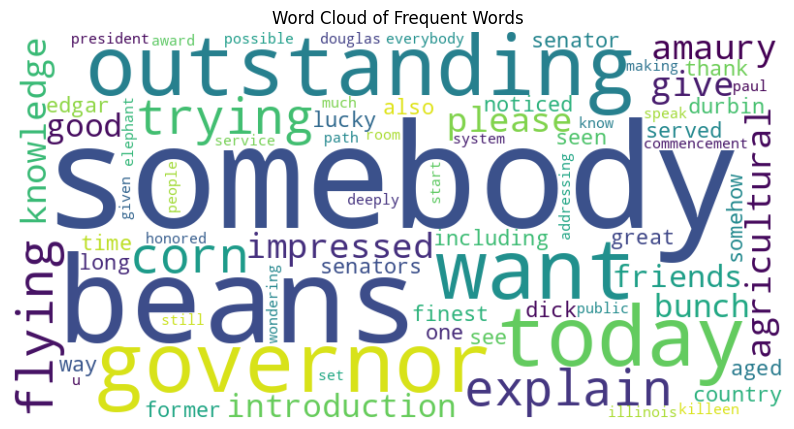

In [16]:
!pip install wordcloud
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word2count_filtered)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Frequent Words")
plt.show()